# EL-GHALI MOHAMED

# Régression Linéaire Multiple avec PyTorch
Nous utilisons le framework **PyTorch** pour implémenter notre régression linéaire multiple.

In [16]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Création du petit dataset (Mock Data)
# ==========================================

data_dict = {
    "Downtime_Minutes": [10, 20, 15, 30, 45, 5, 60, 25, 40, 50],
    "Users_Affected": [100, 250, 150, 350, 500, 50, 700, 300, 450, 600],
    "Transactions": [500, 1000, 800, 1500, 2000, 200, 3000, 1200, 1800, 2500],
    "Data_Risk_Transactions_Lost": [5, 10, 8, 15, 20, 2, 30, 12, 18, 25],
    "Financial_Loss_INR": [5000, 12000, 8000, 18000, 25000, 2000, 35000, 15000, 22000, 30000]
}
# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)

## 2. Préparation des Tenseurs PyTorch

Nous convertissons directement les données brutes  en tenseurs PyTorch de type `float32`.

In [17]:
# Sélection des 4 variables explicatives et de la cible, conversion directe en tenseurs
# On précise dtype=torch.float (qui équivaut à float32), le standard habituel pour PyTorch
X = torch.tensor(data[["Downtime_Minutes", "Users_Affected", "Transactions", "Data_Risk_Transactions_Lost"]].values, dtype=torch.float)
Y = torch.tensor(data[["Financial_Loss_INR"]].values, dtype=torch.float)

## 3. Définition du Modèle et Hyperparamètres

Nous utilisons la couche `nn.Linear` native de PyTorch.
Nous remettons délibérément les poids et le biais initiaux de PyTorch à zéro avec `torch.no_grad()` pour avoir un point de départ propre, et nous fixons le `lr` à `1e-8`.

In [18]:
# Définition du modèle : 4 caractéristiques en entrée et 1 valeur à prédire en sortie
model = torch.nn.Linear(in_features=4, out_features=1, dtype=torch.float)

# On force l'initialisation des poids à 0 pour éviter une explosion immédiate avec les données non normalisées
with torch.no_grad():
    model.weight.fill_(0.0)
    model.bias.fill_(0.0)

# Fonction de coût (Erreur Quadratique Moyenne - MSE)
criterion = torch.nn.MSELoss()

# Optimiseur SGD avec un taux d'apprentissage très faible
optimizer = torch.optim.SGD(model.parameters(), lr=1e-8)

## 4. Boucle d'entraînement (Training Loop)

La boucle standard PyTorch en 5 étapes. Nous augmentons le nombre d'époques à 250

In [19]:
losses = []
epochs = 250

for epoch in range(epochs):
    # 1: On réinitialise les gradients à zéro
    optimizer.zero_grad()

    # 2: Prédictions (Forward pass)
    output = model(X)

    # 3: Calcul de la fonction de coût
    loss = criterion(output, Y)

    # 4: PyTorch calcule les gradients automatiquement (Backward pass)
    loss.backward()

    # 5: Mise à jour des poids
    optimizer.step()

    # Sauvegarde de l'erreur (.item() extrait le nombre pur du tenseur)
    losses.append(loss.item())

    # Suivi de la convergence (toutes les 50 époques)
    if epoch % 50 == 0:
        print(f"Epoch {epoch:5} | Loss: {loss.item():.2f}")

Epoch     0 | Loss: 401999968.00
Epoch    50 | Loss: 1416206.00
Epoch   100 | Loss: 544793.19
Epoch   150 | Loss: 542579.62
Epoch   200 | Loss: 542255.06


## 5. Résultats et Visualisation


Poids finaux trouvés (Weights): [[ 0.23714486  2.7645726  11.283111    0.1128311 ]]
Biais final trouvé (Bias): [0.00521051]


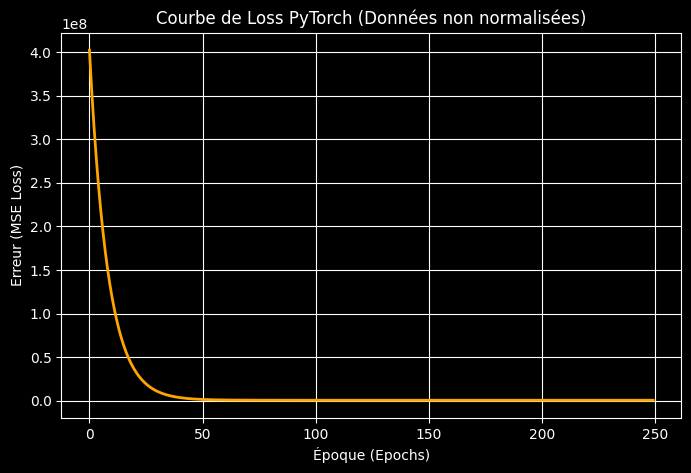

In [20]:
# Affichage des paramètres trouvés par le modèle
# .detach().numpy() permet d'extraire les valeurs hors du graphe de calcul (Autograd)
print("\nPoids finaux trouvés (Weights):", model.weight.detach().numpy())
print("Biais final trouvé (Bias):", model.bias.detach().numpy())

# Visualisation de la courbe d'erreur
plt.figure(figsize=(8, 5))
plt.plot(losses, color='orange', linewidth=2)
plt.xlabel("Époque (Epochs)")
plt.ylabel("Erreur (MSE Loss)")
plt.title("Courbe de Loss PyTorch (Données non normalisées)")
plt.grid(True)
plt.show()